# Mixing below a confluence

## Overview

**Purpose**: Trace D8 flowlines from sample points to the watershed outlet and analyze ¹⁰Be concentration and erosion rate evolution downstream of the Teno-Lontué confluence (where CT-5 and CT-6 tributaries merge).

**Inputs**:
- Flow direction and drainage area rasters (`data/dem/fd_utm30m`, `data/dem/area_utm30m`) — external DEM-derived data
- Sample points shapefile (`data/shapefiles/sample_points/`)
- `MataquitoSampleData.xlsx` via `mataquito.sample_data`

**Outputs**:
- Stream network visualizations with distances from confluence and outlet
- Distance vs. ¹⁰Be concentration and erosion rate plots for the downstream sequence (CT-4 → CT-10 → CT-11 → CT-8)
- Mixing length scale analysis (violin plots of bootstrap mixing proportions vs. downstream distance)
- Corrected flowline shapefiles

**Method**: Projects sample points onto D8-derived flowlines, computes distances from the Teno-Lontué confluence and from the watershed outlet, then plots how cosmogenic and provenance signals evolve downstream. Reference bands for the CT-5 and CT-6 tributary end-members show whether downstream samples are well-mixed.

#### This notebook analyses the mixing from CT-5 and CT-6 parents to the downstream children, CT-4 -> CT-10 -> CT-11 -> CT-8.2
To better understand this downstream mixing analyses of both detrital zircon data and Be-10 data are used

### Understanding downstream mixing vs zircon distribution

In [1]:
import numpy as np
import matplotlib.pylab as plt
import pandas as pd
import geopandas as gpd
import rasterio
import csv
import sys; sys.path.insert(0, '..')
from rasterio.plot import show
from geopy.distance import geodesic
from shapely.geometry import LineString, Point

from mataquito.sample_data import load_samples
from mataquito.flowlines import (
    create_flowlines_from_raster,
    calculate_distance_along_line,
    substring_line,
    calculate_stream_distances_from_confluence,
    calculate_stream_distances_from_outlet,
)

In [2]:
# Load sample data from the canonical Excel file
df = load_samples()
print(df)

   Sample_ID Sample_Type   Latitude  Longitude  Source_Area  Elevation  \
0       CT-1  river sand -35.261470 -71.042330     1385.185        550   
1       CT-2  river sand -35.038830 -72.067050     5760.128         11   
2       CT-3  river sand -35.100380 -71.946720      189.205         18   
3       CT-4  river sand -35.027690 -71.487020     4706.717        111   
4       CT-5  river sand -34.962640 -71.359940     1495.897        155   
5       CT-6  river sand -34.984880 -71.342700     2573.245        158   
6       CT-7  river sand -35.003550 -70.827530     1207.810        631   
7       CT-8  river sand -35.092222 -71.647745     4950.395         78   
8       CT-9  river sand -35.046389 -72.101111     6189.716          9   
9      CT-10  river sand -35.049444 -71.550000     4864.942        102   
10     CT-11  river sand -35.064167 -71.610278     4913.334         89   

    Virtual_Elevation  Surface_Production_Rate  Shielding_Factor  Quartz  \
0             2261.20              

In [3]:
# Core flowline functions (create_flowlines_from_raster, calculate_distance_along_line,
# substring_line, calculate_stream_distances_from_confluence, calculate_stream_distances_from_outlet)
# are imported from mataquito.flowlines above.

# Visualization and orchestration functions remain here.

def create_visualization_with_fixed_distances(samples_gdf, flowlines_gdf, distances, confluence_point):
    """Create a visualization showing the stream network with corrected distances."""
    fig, ax = plt.subplots(1, 1, figsize=(12, 10))
    flowlines_gdf.plot(ax=ax, color='blue', linewidth=2, alpha=0.7, label='Generated Flowlines', zorder=1)
    samples_gdf.plot(ax=ax, color='red', markersize=100, alpha=0.8, label='Sample Points', zorder=10)
    if confluence_point:
        confluence_gdf = gpd.GeoDataFrame([{'geometry': confluence_point}], crs=samples_gdf.crs)
        confluence_gdf.plot(ax=ax, color='green', markersize=200, marker='*',
                           label='Confluence Point', alpha=0.9)
    for idx, sample in samples_gdf.iterrows():
        ax.annotate(sample['Name'],
                   xy=(sample.geometry.x, sample.geometry.y),
                   xytext=(5, 5), textcoords='offset points',
                   fontsize=10, fontweight='bold', zorder=20)
    for sample_name in distances.keys():
        if sample_name in samples_gdf['Name'].values:
            sample_point = samples_gdf[samples_gdf['Name'] == sample_name].geometry.iloc[0]
            distance = distances[sample_name]
            label = f"{distance:.1f} km from confluence"
            ax.annotate(label,
                       xy=(sample_point.x, sample_point.y),
                       xytext=(10, -15), textcoords='offset points',
                       fontsize=8,
                       bbox=dict(boxstyle="round,pad=0.1", facecolor="lightblue", alpha=0.6))
    ax.set_xlabel('Easting (UTM)')
    ax.set_ylabel('Northing (UTM)')
    ax.set_title('Stream Network: Mataquito River Watershed')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    return fig, ax


def run_complete_analysis_with_fixed_distances():
    """Run the complete confluence distance analysis with visualization."""
    flow_direction_path = "../data/dem/fd_utm30m"
    area_path = "../data/dem/area_utm30m"
    samples_path = "../data/shapefiles/sample_points/mataquitosamplepoints_corrected_for_flow_30mDEM.shp"

    samples_gdf = gpd.read_file(samples_path)
    flowlines_gdf = create_flowlines_from_raster(flow_direction_path, area_path, samples_gdf, min_drainage_area=50)
    print(f"Generated {len(flowlines_gdf)} flowlines")

    distances, confluence_point = calculate_stream_distances_from_confluence(
        samples_gdf, flowlines_gdf,
        target_samples=['CT-4', 'CT-10', 'CT-11', 'CT-8'],
        tributary_samples=['CT-5', 'CT-6']
    )

    fig, ax = create_visualization_with_fixed_distances(samples_gdf, flowlines_gdf, distances, confluence_point)
    plt.savefig('../figures/mixing/corrected_confluence_distances_visualization.png', dpi=300, bbox_inches='tight')
    plt.show()
    flowlines_gdf.to_file("../data/shapefiles/flowlines/corrected_flowlines.shp")
    return distances, confluence_point

Generated 11 flowlines


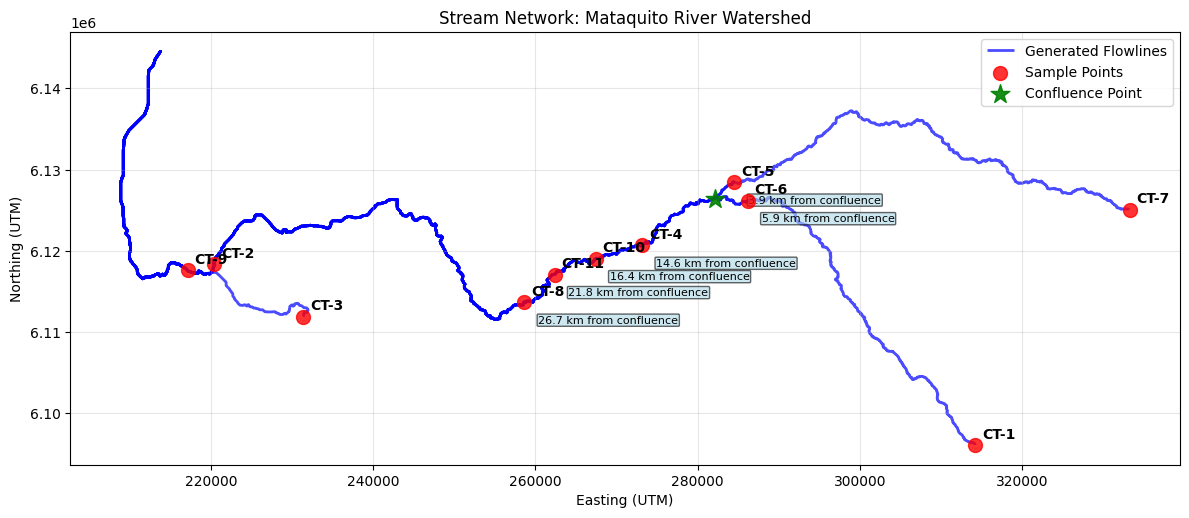

/var/folders/q2/0xd1lglj6lzdx_7wr72bt7t00000gp/T/ipykernel_97514/1974195357.py:59: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  flowlines_gdf.to_file("../data/shapefiles/flowlines/corrected_flowlines.shp")
/Users/Glong1/anaconda3/lib/python3.11/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'sample_name' to 'sample_nam'
  ogr_write(


In [4]:
# Example usage:
if __name__ == "__main__":
    # Run the complete analysis
    distances, confluence_point = run_complete_analysis_with_fixed_distances()

In [18]:
def plot_downstream_violin_filtered(csv_files, sample_names, df_coords, best_fit_values_list=None, 
                                  labels=None, colors=None, title="Downstream Mixing Length Scales",
                                  figsize=(15, 8), violin_width=1, save_path=None, filter_zeros_ones=True,
                                  pre_calculated_distances=None):

    if pre_calculated_distances is not None:
        distances = pre_calculated_distances
    else:
        print("Need to provide distances")
    
    sorted_samples = sorted(sample_names, key=lambda x: distances[x], reverse=True)
    sorted_distances = [distances[s] for s in sorted_samples]
    
    sample_to_index = {sample: i for i, sample in enumerate(sample_names)}
    sorted_csv_files = [csv_files[sample_to_index[s]] for s in sorted_samples]
    
    if best_fit_values_list:
        sorted_best_fit = [best_fit_values_list[sample_to_index[s]] for s in sorted_samples]
    else:
        sorted_best_fit = None
    
    fig, ax = plt.subplots(figsize=figsize)
    
    filtered_data_dict = {}
    all_positions = []
    sample_midpoints = []
    
    position_counter = 1

    # ---- spacing controls (prevents overlap & keeps groups centered) ----
    component_spacing = 1.3
    group_spacing = 3

    for i, (sample, csv_file, distance) in enumerate(zip(sorted_samples, sorted_csv_files, sorted_distances)):
        
        mixing_data = []
        with open(csv_file, 'r') as file:
            csvfile = csv.reader(file)
            next(csvfile)
            for row in csvfile:
                row_values = [float(val) for val in row]
                if filter_zeros_ones:
                    if not any(val in [0.0, 1.0] for val in row_values):
                        mixing_data.append(row_values)
                else:
                    mixing_data.append(row_values)
        
        mixing_data = np.array(mixing_data)
        filtered_data_dict[sample] = mixing_data
        
        if len(mixing_data) == 0:
            print(f"Warning: No valid data for sample {sample} after filtering")
            continue
        
        if filter_zeros_ones:
            print(f"Sample {sample}: {len(mixing_data)} rows after filtering out 0s and 1s")
        
        n_components = mixing_data.shape[1]
        data_for_violin = [mixing_data[:, j] for j in range(n_components)]
        
        if colors is None:
            default_colors = ['red', 'blue', 'green', 'orange', 'purple']
            colors = default_colors[:n_components]
        
        if labels is None:
            labels = [f'Component {j+1}' for j in range(n_components)]
        
        # ---- centered group positions ----
        group_height = (n_components - 1) * component_spacing
        
        sample_positions = [
            position_counter + j * component_spacing
            for j in range(n_components)
        ]
        
        group_midpoint = position_counter + group_height / 2
        sample_midpoints.append(group_midpoint)
        
        parts = ax.violinplot(
            data_for_violin,
            positions=sample_positions,
            vert=False,
            widths=violin_width,
            showmeans=False,
            showextrema=False,
            showmedians=True
        )
        
        for j, pc in enumerate(parts['bodies']):
            pc.set_color(colors[j])
            pc.set_edgecolor('black')
            pc.set_alpha(1)
        
        parts['cmedians'].set_edgecolor('black')
        parts['cmedians'].set_linewidth(2)
        
        if sorted_best_fit:
            for j, value in enumerate(sorted_best_fit[i]):
                ax.scatter(value, sample_positions[j], color='white', s=80, 
                          edgecolor='black', linewidth=1, zorder=10, marker='D')
        
        all_positions.extend(sample_positions)
        
        # separator line between samples
        if i < len(sorted_samples) - 1:
            separator_y = position_counter + group_height + group_spacing / 2
            ax.axhline(y=separator_y, color='black', linestyle='-', linewidth=1.5, alpha=0.3)
        
        position_counter += group_height + group_spacing

    ax.set_xlim(0, 1)
    ax.set_ylim(0.5, max(all_positions) + 0.5)
    ax.set_yticks([])
    ax.set_xlabel('Mixing Proportion', fontsize=12)
    
    # ---- sample labels centered on group midpoints ----
    offset = component_spacing * 0.35  # data units, scales with spacing

    for i, sample in enumerate(sorted_samples):
        distance = sorted_distances[i]
        midpoint = sample_midpoints[i]
        
        ax.text(-0.02, midpoint + offset, sample,
                transform=ax.get_yaxis_transform(),  # REMOVE THIS LINE
                verticalalignment='center',
                horizontalalignment='right',
                fontsize=11,
                fontweight='bold')
        
        ax.text(-0.02, midpoint - offset, f"({distance:.1f} km)",
                transform=ax.get_yaxis_transform(),  # REMOVE THIS LINE
                verticalalignment='center',
                horizontalalignment='right',
                fontsize=10,
                style='italic')
            
    legend_elements = []
    for label, color in zip(labels, colors):
        legend_elements.append(
            plt.Rectangle((0, 0), 1, 1, facecolor=color,
                          edgecolor='black', alpha=1, label=label)
        )
    
    legend_elements.append(
        plt.Line2D([0], [0], color='black', linewidth=2, label='Median')
    )
    
    if sorted_best_fit:
        legend_elements.append(
            plt.Line2D([0], [0], marker='D', color='white',
                       markerfacecolor='white',
                       markeredgecolor='black',
                       markersize=8, linewidth=0,
                       markeredgewidth=1, label='Best-fit')
        )
    
    ax.legend(handles=legend_elements, loc='lower left',
              frameon=True, fancybox=False, shadow=False,
              fontsize=10, bbox_to_anchor=(0.02, 0.06))
    
    if filter_zeros_ones:
        title += " (Filtered: 0 & 1)"
    #ax.set_title(title, fontsize=14, fontweight='bold')
    
    ax.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    return fig, ax, filtered_data_dict

Sample CT-8: 10000 rows after filtering out 0s and 1s
Sample CT-11: 9991 rows after filtering out 0s and 1s
Sample CT-10: 9999 rows after filtering out 0s and 1s
Sample CT-4: 9898 rows after filtering out 0s and 1s


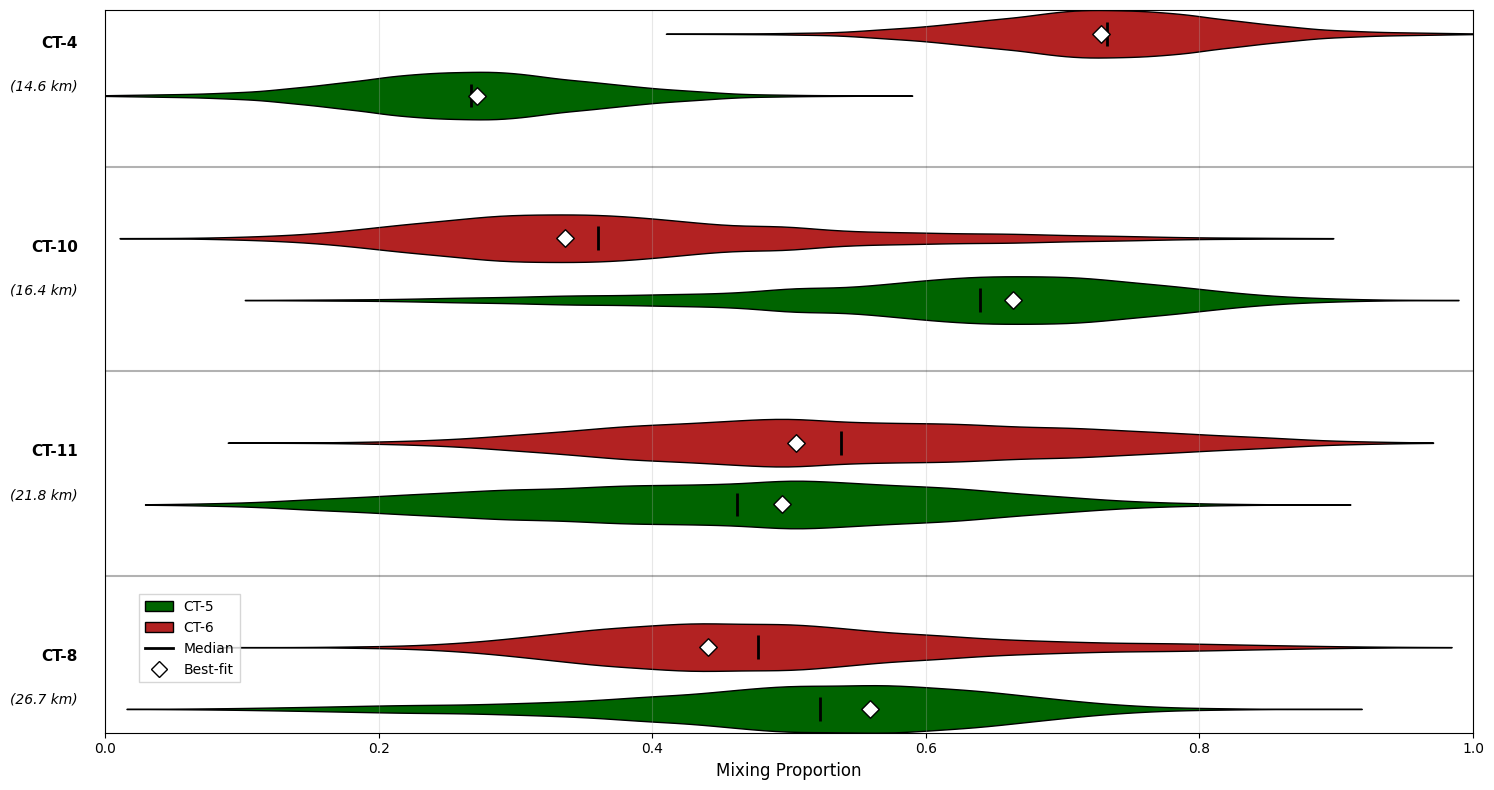

In [21]:
# Plot CT-5 and CT-6 mixing for samples at different downstream distances with filtering.    
# Define sample data in original order (will be sorted by distance later)
sample_names = ['CT-4', 'CT-10', 'CT-11', 'CT-8']
csv_files = [
        '../results/mixing_coefficients/mix_coeffs_all_ct-5_ct-6_to_ct-4.csv',
        '../results/mixing_coefficients/mix_coeffs_all_ct-5_ct-6_to_ct-10.csv',
        '../results/mixing_coefficients/mix_coeffs_all_ct-5_ct-6_to_ct-11.csv',
        '../results/mixing_coefficients/mix_coeffs_all_ct-5_ct-6_to_ct-8.2.csv'
    ]
    
# Best-fit mixing proportions for each sample (corresponding to sample_names order)
best_fit_values = [
        [0.272, 0.728],  # CT-4: 27.2% CT-5, 72.8% CT-6
        [0.664, 0.336],  # CT-10: 66.4% CT-5, 33.6% CT-6
        [0.495, 0.505],  # CT-11: 49.5% CT-5, 50.5% CT-6
        [0.559, 0.441]   # CT-8: 55.9% CT-5, 44.1% CT-6
    ]
    
# Create plot with legend and filtering
fig, ax, filtered_data = plot_downstream_violin_filtered(
    csv_files=csv_files,
    sample_names=sample_names,
    df_coords=df,
    best_fit_values_list=best_fit_values,
    labels=['CT-5', 'CT-6'],  # Component labels for legend
    colors=['darkgreen', 'firebrick'],   # Colors for CT-6 and CT-5 respectively
    #title='CT-5 + CT-6 Mixing: Downstream Length Scales',
    save_path='../figures/mixing/downstream_mixing_length_scales_filtered.png',
    filter_zeros_ones=True,    # Filter out end-member dominated samples
    pre_calculated_distances=distances
    )
    
plt.show()

## Be-10 downstream mixing

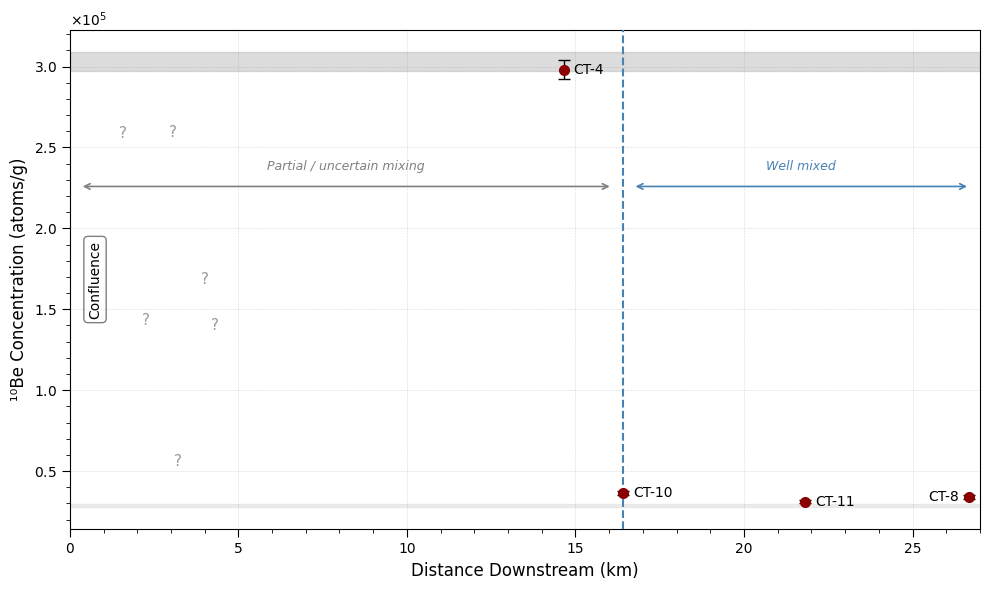

  sample   distance  be10_conc  be10_uncert
0   CT-4  14.646537     298000         5920
1  CT-10  16.399477      36400         1280
2  CT-11  21.821582      31100         1040
3   CT-8  26.685025      33800         1240


In [7]:
samples = ['CT-4', 'CT-10', 'CT-11', 'CT-8']
distances = distances

# Build plot data from downstream samples
plot_data = []
for sample in samples:
    row = df[df['Sample_ID'].str.contains(sample, case=False, na=False)]
    if not row.empty and sample in distances:
        r = row.iloc[0]
        be10_conc = r['10Be_concentration']
        be10_uncert = r['10Be_concentration_uncertainty']
        if pd.notna(be10_conc):
            plot_data.append({
                'sample': r['Sample_ID'],
                'distance': distances[sample],
                'be10_conc': be10_conc,
                'be10_uncert': be10_uncert if pd.notna(be10_uncert) else 0
            })

plot_df = pd.DataFrame(plot_data).sort_values('distance')

fig, ax = plt.subplots(figsize=(10, 6))
ax.set_xlim(0, 27)

# Reference bands for tributary end-members CT-5 and CT-6
ref_colors = {'CT-5': 'lightgray', 'CT-6': 'darkgray'}
for sample in ['CT-5', 'CT-6']:
    row = df[df['Sample_ID'].str.contains(sample, case=False, na=False)]
    if not row.empty:
        r = row.iloc[0]
        if pd.notna(r['10Be_concentration']):
            conc = r['10Be_concentration']
            uncert = r['10Be_concentration_uncertainty'] if pd.notna(r['10Be_concentration_uncertainty']) else 0
            ax.axhspan(conc - uncert, conc + uncert, alpha=0.4,
                       color=ref_colors[sample], zorder=1,
                       label=f"{sample}: {conc:.2e} ± {uncert:.2e}")

# Plot data points with error bars
ax.errorbar(plot_df['distance'], plot_df['be10_conc'], yerr=plot_df['be10_uncert'],
            fmt='o', markersize=7, capsize=4, capthick=1, linewidth=1,
            color='darkred', ecolor='black', markerfacecolor='darkred', zorder=6)

# Sample labels — flip alignment and offset for samples near the right edge
x_max = ax.get_xlim()[1]
for _, row in plot_df.iterrows():
    near_edge = row['distance'] > x_max - 3
    offset = -0.3 if near_edge else 0.3
    ha = 'right' if near_edge else 'left'
    ax.text(row['distance'] + offset, row['be10_conc'], row['sample'],
            va='center', ha=ha, fontsize=10, zorder=6, clip_on=True)

ct10_x = distances['CT-10']
y_max = ax.get_ylim()[1]

# Vertical line at mixing transition (CT-10)
ax.axvline(x=ct10_x, color='steelblue', linestyle='--', linewidth=1.5, zorder=3)

# Annotate zones with arrows
ax.annotate('', xy=(ct10_x - 0.3, y_max * 0.7), xytext=(0.3, y_max * 0.7),
            arrowprops=dict(arrowstyle='<->', color='gray', lw=1.2))
ax.text(ct10_x / 2, y_max * 0.75, 'Partial / uncertain mixing',
        ha='center', va='top', fontsize=9, color='gray', style='italic')

ax.annotate('', xy=(ax.get_xlim()[1] - 0.3, y_max * 0.7), xytext=(ct10_x + 0.3, y_max * 0.7),
            arrowprops=dict(arrowstyle='<->', color='steelblue', lw=1.2))
ax.text((ct10_x + ax.get_xlim()[1]) / 2, y_max * 0.75, 'Well mixed',
        ha='center', va='top', fontsize=9, color='steelblue', style='italic')

# Question marks evenly spaced vertically in uncertain mixing zone
rng = np.random.default_rng(1)
for _ in range(6):
    x = rng.uniform(1, 5)
    y = rng.uniform(0.5e5, 2.7e5)
    ax.text(x, y, '?', fontsize=11, ha='center', va='center',
            color='black', alpha=0.4, zorder=5)

# Confluence label on left spine
ax.text(0.02, 0.5, 'Confluence', transform=ax.transAxes,
        fontsize=10, va='center', ha='left', rotation=90,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

# Axis formatting
ax.set_xlabel('Distance Downstream (km)', fontsize=12)
ax.set_ylabel('¹⁰Be Concentration (atoms/g)', fontsize=12)
ax.yaxis.set_major_formatter(plt.ScalarFormatter(useMathText=True))
ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
ax.tick_params(axis='both', which='major', labelsize=10, direction='out', length=6)
ax.tick_params(axis='both', which='minor', direction='out', length=3)
ax.minorticks_on()
ax.grid(True, linestyle='--', linewidth=0.4, alpha=0.3, color='gray')

plt.tight_layout()
plt.savefig('../figures/mixing/downstream_mixing_Be-10.png')
plt.show()
print(plot_df[['sample', 'distance', 'be10_conc', 'be10_uncert']])

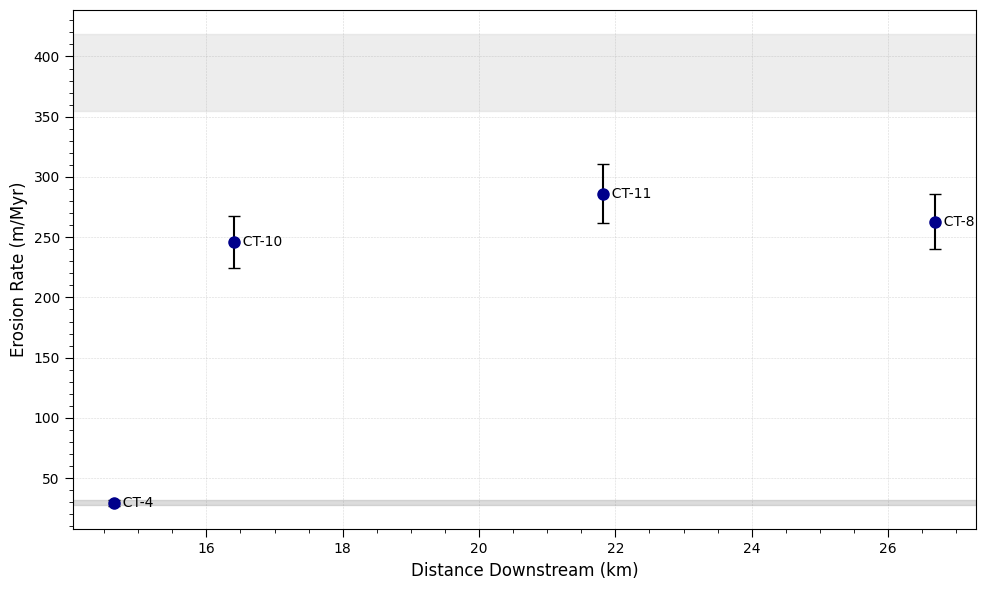

  sample   distance  erosion_rate  erosion_uncert
0   CT-4  14.646537          29.6            2.44
1  CT-10  16.399477         246.0           21.30
2  CT-11  21.821582         286.0           24.50
3   CT-8  26.685025         263.0           22.90


In [8]:
# Plotting the Erosion Rate vs distance downstream, using external uncertainty which accounts for all uncertainties
# Only use downstream sequence samples
samples = ['CT-4', 'CT-10', 'CT-11', 'CT-8']
# Load calculated distances
distances = distances
# Get data for plotting
plot_data = []
for sample in samples:
    row = df[df['Sample_ID'].str.contains(sample, case=False, na=False)]
    if not row.empty and sample in distances:
        r = row.iloc[0]
        erosion_rate = r['Erosion_rate']
        erosion_uncert = r['Erosion_rate_uncertainty_external']
        
        if pd.notna(erosion_rate):
            plot_data.append({
                'sample': r['Sample_ID'],
                'distance': distances[sample],
                'erosion_rate': erosion_rate,
                'erosion_uncert': erosion_uncert if pd.notna(erosion_uncert) else 0
            })
# Convert to DataFrame and sort by distance
plot_df = pd.DataFrame(plot_data).sort_values('distance')
# Create plot with improved formatting
fig, ax = plt.subplots(figsize=(10, 6))
# Extract data for error bars
x_vals = plot_df['distance'].values
y_vals = plot_df['erosion_rate'].values
y_err = plot_df['erosion_uncert'].values

# Get CT-5 and CT-6 erosion rates for reference bars
ref_samples = ['CT-5', 'CT-6']
ref_data = {}
for sample in ref_samples:
    row = df[df['Sample_ID'].str.contains(sample, case=False, na=False)]
    if not row.empty:
        r = row.iloc[0]
        if pd.notna(r['Erosion_rate']):
            ref_data[sample] = {
                'rate': r['Erosion_rate'],
                'uncert': r['Erosion_rate_uncertainty_external'] if pd.notna(r['Erosion_rate_uncertainty_external']) else 0
            }

# Add reference bands for CT-5 and CT-6
colors = {'CT-5': 'lightgray', 'CT-6': 'darkgray'}
for sample, data in ref_data.items():
    ax.axhspan(data['rate'] - data['uncert'], data['rate'] + data['uncert'],
               alpha=0.4, color=colors[sample], label=f"{sample}: {data['rate']:.1f} ± {data['uncert']:.1f} m/Myr")

# Plot with error bars
ax.errorbar(x_vals, y_vals, yerr=y_err, 
           fmt='o', markersize=8, capsize=4, capthick=1, 
           linewidth=1.5, color='darkblue', ecolor='black', 
           markerfacecolor='darkblue',
           zorder=3)
# Add sample labels
for _, row in plot_df.iterrows():
    ax.text(row['distance'], row['erosion_rate'], f"  {row['sample']}", 
            verticalalignment='center', fontsize=10, zorder=4)
    
ax.grid(True, linestyle='--', linewidth=0.4, alpha=0.3, color='gray')

# Add minor ticks on both x and y axes
ax.tick_params(axis='both', which='major', labelsize=10, direction='out', length=6)
ax.tick_params(axis='both', which='minor', direction='out', length=3)
ax.minorticks_on()

# Labels and title
ax.set_xlabel('Distance Downstream (km)', fontsize=12)
ax.set_ylabel('Erosion Rate (m/Myr)', fontsize=12)
#ax.set_title('Erosion Rate vs Distance Downstream', fontsize=14)
plt.tight_layout()
plt.savefig('../figures/mixing/downstream_mixing_erosionrate.png')
plt.show()
print(plot_df[['sample', 'distance', 'erosion_rate', 'erosion_uncert']])

## Plotting all samples based on distance

#### Definitions for calculations and plotting

In [9]:
# calculate_stream_distances_from_outlet is imported from mataquito.flowlines above.

def run_outlet_distance_analysis():
    """Run the complete analysis calculating distances from outlet."""
    flow_direction_path = "../data/dem/fd_utm30m"
    area_path = "../data/dem/area_utm30m"
    samples_path = "../data/shapefiles/sample_points/mataquitosamplepoints_corrected_for_flow_30mDEM.shp"

    samples_gdf = gpd.read_file(samples_path)
    flowlines_gdf = create_flowlines_from_raster(flow_direction_path, area_path, samples_gdf, min_drainage_area=50)
    print(f"Generated {len(flowlines_gdf)} flowlines")

    outlet_distances, outlet_point = calculate_stream_distances_from_outlet(
        samples_gdf, flowlines_gdf, outlet_coords=(208913.7, 6126075.0)
    )
    return outlet_distances, outlet_point

In [10]:
def create_visualization_with_outlet_distances(samples_gdf, flowlines_gdf, distances, outlet_point):
    """
    Create a visualization showing the stream network with distances from outlet.
    """
    import matplotlib.pyplot as plt
    import geopandas as gpd
    
    # Create plot
    fig, ax = plt.subplots(1, 1, figsize=(12, 10))
    
    # Plot flowlines FIRST with explicit low zorder (background layer)
    flowlines_gdf.plot(ax=ax, color='blue', linewidth=2, alpha=0.7, label='Generated Flowlines', zorder=1)
    
    # Plot sample points with high zorder (on top of flowlines)
    samples_gdf.plot(ax=ax, color='red', markersize=100, alpha=0.8, label='Sample Points', zorder=10)
    
    # Plot outlet point with high zorder (on top of flowlines)
    if outlet_point:
        outlet_gdf = gpd.GeoDataFrame([{'geometry': outlet_point}], crs=samples_gdf.crs)
        outlet_gdf.plot(ax=ax, color='green', markersize=50, marker='s', 
                       label='River Outlet', alpha=0.9, linewidth=2, zorder=10)
    
    # Add sample labels with highest zorder (on top of everything)
    for idx, sample in samples_gdf.iterrows():
        ax.annotate(sample['Name'], 
                   xy=(sample.geometry.x, sample.geometry.y),
                   xytext=(5, 5), textcoords='offset points',
                   fontsize=10, fontweight='bold', zorder=20)
    
    # Add distance labels with highest zorder (on top of everything)
    for sample_name in distances.keys():
        if sample_name in samples_gdf['Name'].values:
            sample_point = samples_gdf[samples_gdf['Name'] == sample_name].geometry.iloc[0]
            distance = distances[sample_name]
            
            label = f"{distance:.1f} km from outlet"
            
            ax.annotate(label, 
                       xy=(sample_point.x, sample_point.y),
                       xytext=(10, -15), textcoords='offset points',
                       fontsize=8, 
                       bbox=dict(boxstyle="round,pad=0.1", facecolor="lightyellow", alpha=0.6),
                       zorder=20)
    
    # Set labels and title
    ax.set_xlabel('Easting (UTM)')
    ax.set_ylabel('Northing (UTM)')
    ax.set_title('Stream Network: Mataquito River Watershed - Distances from Outlet')
    ax.legend()
    
    # Grid and formatting
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    
    # Save the plot
    plt.savefig('../figures/mixing/outlet_distances_visualization.png', dpi=300, bbox_inches='tight')
    
    return fig, ax

### Distances from outlet

Generated 11 flowlines


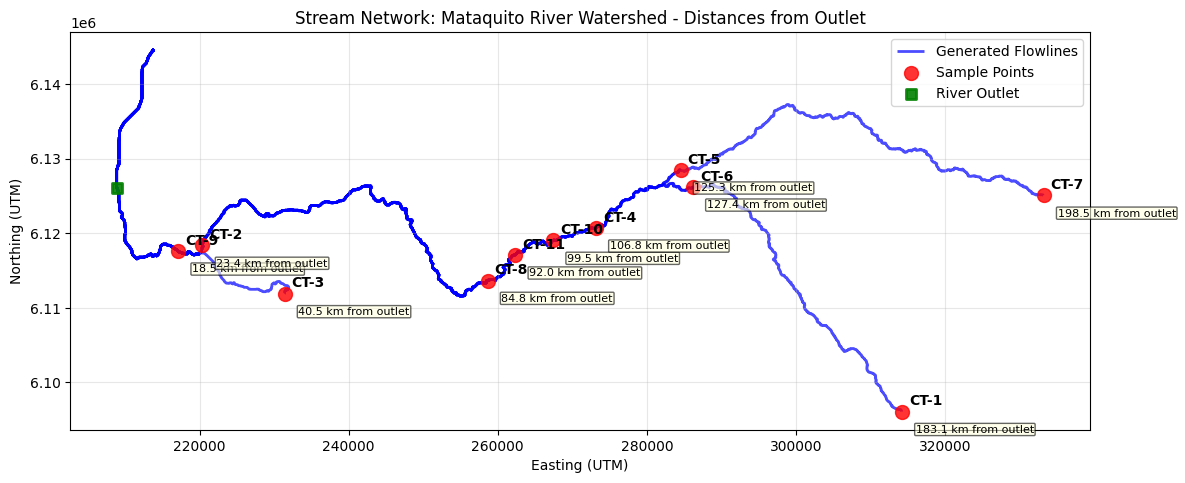

In [11]:
# Run the outlet distance analysis
outlet_distances, outlet_point = run_outlet_distance_analysis()

# Load the data (if not already loaded)
samples_gdf = gpd.read_file("../data/shapefiles/sample_points/mataquitosamplepoints_corrected_for_flow_30mDEM.shp")

# Create flowlines (if not already created)
flowlines_gdf = create_flowlines_from_raster(
    "../data/dem/fd_utm30m", 
    "../data/dem/area_utm30m", 
    samples_gdf,
    min_drainage_area=50
)

# Create visualization
fig, ax = create_visualization_with_outlet_distances(
    samples_gdf, flowlines_gdf, outlet_distances, outlet_point
)
plt.show()

In [12]:
def plot_all_samples_from_outlet(df, distances):
    import pandas as pd
    import matplotlib.pyplot as plt

    samples = [f'CT-{i}' for i in range(1, 12)]

    color_map = {
        'CT-5': ('#D55E00', 'Teno'),
        'CT-7': ('#D55E00', 'Teno'),
        'CT-6': ('#009E73', 'Lontue'),
        'CT-1': ('#009E73', 'Lontue'),
        'CT-4': ('#0072B2', 'Below Confluence'),
        'CT-10': ('#0072B2', 'Below Confluence'),
        'CT-11': ('#0072B2', 'Below Confluence'),
        'CT-8': ('#0072B2', 'Below Confluence'),
        'CT-2': ('#E69F00', 'Outlet'),
        'CT-9': ('#E69F00', 'Outlet'),
        'CT-3': ('#CC79A7', 'CT-3'),
    }

    plot_data = []
    for sample in samples:
        row = df[df['Sample_ID'].str.contains(sample, case=False, na=False)]
        if not row.empty and sample in distances:
            r = row.iloc[0]
            erosion_rate = r['Erosion_rate']
            erosion_uncert = r['Erosion_rate_uncertainty_external']
            if pd.notna(erosion_rate):
                display_name = 'CT-8.2' if sample == 'CT-8' else r['Sample_ID']
                plot_data.append({
                    'sample': display_name,
                    'sample_key': sample,
                    'distance': distances[sample],
                    'erosion_rate': erosion_rate,
                    'erosion_uncert': erosion_uncert if pd.notna(erosion_uncert) else 0
                })

    plot_df = pd.DataFrame(plot_data).sort_values('distance')

    confluence_x = distances['CT-4'] + 14.6

    fig, ax = plt.subplots(figsize=(10, 6))

    legend_handles = {}

    for _, row in plot_df.iterrows():
        key = row['sample_key']
        color, group = color_map.get(key, ('gray', 'Unknown'))
        handle = ax.errorbar(row['distance'], row['erosion_rate'], yerr=row['erosion_uncert'],
                   fmt='o', markersize=8, capsize=4, capthick=1,
                   linewidth=1.5, color=color, ecolor='black',
                   markerfacecolor=color, zorder=3,
                   label=group if group not in legend_handles else '')
        if group not in legend_handles:
            legend_handles[group] = handle

    ax.axvline(x=confluence_x, color='black', linestyle='--', linewidth=1.2,
               label='Confluence', zorder=2)

    for _, row in plot_df.iterrows():
        ax.text(row['distance'], row['erosion_rate'], f"  {row['sample']}",
                verticalalignment='center', fontsize=10, zorder=4)

    ax.legend(fontsize=10)
    ax.grid(True, linestyle='--', linewidth=0.4, alpha=0.3, color='gray')
    ax.tick_params(axis='both', which='major', labelsize=10, direction='out', length=6)
    ax.tick_params(axis='both', which='minor', direction='out', length=3)
    ax.minorticks_on()

    ax.set_xlabel('Distance from Outlet (km)', fontsize=12)
    ax.set_ylabel('Erosion Rate (m/Myr)', fontsize=12)

    plt.tight_layout()
    plt.savefig('../figures/mixing/downstream_mixing_erosionrate_from_outlet.png')
    plt.show()
    print(plot_df[['sample', 'distance', 'erosion_rate', 'erosion_uncert']])

    return plot_df

In [13]:
def plot_be10_concentration_from_outlet(df, distances):
    import pandas as pd
    import matplotlib.pyplot as plt
    
    samples = [f'CT-{i}' for i in range(1, 12)]
    
    # Color groups
    color_map = {
        'CT-5': ('#D55E00', 'Teno'),
        'CT-7': ('#D55E00', 'Teno'),
        'CT-6': ('#009E73', 'Lontue'),
        'CT-1': ('#009E73', 'Lontue'),
        'CT-4': ('#0072B2', 'Below Confluence'),
        'CT-10': ('#0072B2', 'Below Confluence'),
        'CT-11': ('#0072B2', 'Below Confluence'),
        'CT-8': ('#0072B2', 'Below Confluence'),
        'CT-2': ('#E69F00', 'Outlet'),
        'CT-9': ('#E69F00', 'Outlet'),
        'CT-3': ('#CC79A7', 'CT-3'),
    }

    plot_data = []
    for sample in samples:
        row = df[df['Sample_ID'].str.contains(sample, case=False, na=False)]
        if not row.empty and sample in distances:
            r = row.iloc[0]
            be10_conc = r['10Be_concentration']
            be10_uncert = r['10Be_concentration_uncertainty']
            if pd.notna(be10_conc):
                # Use CT-8.2 as display name for CT-8
                display_name = 'CT-8.2' if sample == 'CT-8' else r['Sample_ID']
                plot_data.append({
                    'sample': display_name,
                    'sample_key': sample,
                    'distance': distances[sample],
                    'be10_conc': be10_conc,
                    'be10_uncert': be10_uncert if pd.notna(be10_uncert) else 0
                })

    plot_df = pd.DataFrame(plot_data).sort_values('distance')

    # Confluence line position
    confluence_x = distances['CT-4'] + 14.6

    fig, ax = plt.subplots(figsize=(10, 6))

    # Track labels for legend
    legend_handles = {}

    for _, row in plot_df.iterrows():
        key = row['sample_key']
        color, group = color_map.get(key, ('gray', 'Unknown'))
        handle = ax.errorbar(row['distance'], row['be10_conc'], yerr=row['be10_uncert'],
                   fmt='o', markersize=8, capsize=4, capthick=1,
                   linewidth=1.5, color=color, ecolor='black',
                   markerfacecolor=color, zorder=3,
                   label=group if group not in legend_handles else '')
        if group not in legend_handles:
            legend_handles[group] = handle

    # Confluence vertical line
    ax.axvline(x=confluence_x, color='black', linestyle='--', linewidth=1.2, 
               label='Confluence', zorder=2)

    # Sample labels
    for _, row in plot_df.iterrows():
        ax.text(row['distance'], row['be10_conc'], f"  {row['sample']}",
                verticalalignment='center', fontsize=10, zorder=4)

    ax.legend(fontsize=10)
    ax.grid(True, linestyle='--', linewidth=0.4, alpha=0.3, color='gray')
    ax.tick_params(axis='both', which='major', labelsize=10, direction='out', length=6)
    ax.tick_params(axis='both', which='minor', direction='out', length=3)
    ax.minorticks_on()

    ax.set_xlabel('Distance from Outlet (km)', fontsize=12)
    ax.set_ylabel('¹⁰Be Concentration (atoms/g)', fontsize=12)

    plt.tight_layout()
    plt.savefig('../figures/mixing/downstream_mixing_be10concentration_from_outlet.png')
    plt.show()
    print(plot_df[['sample', 'distance', 'be10_conc', 'be10_uncert']])

    return plot_df

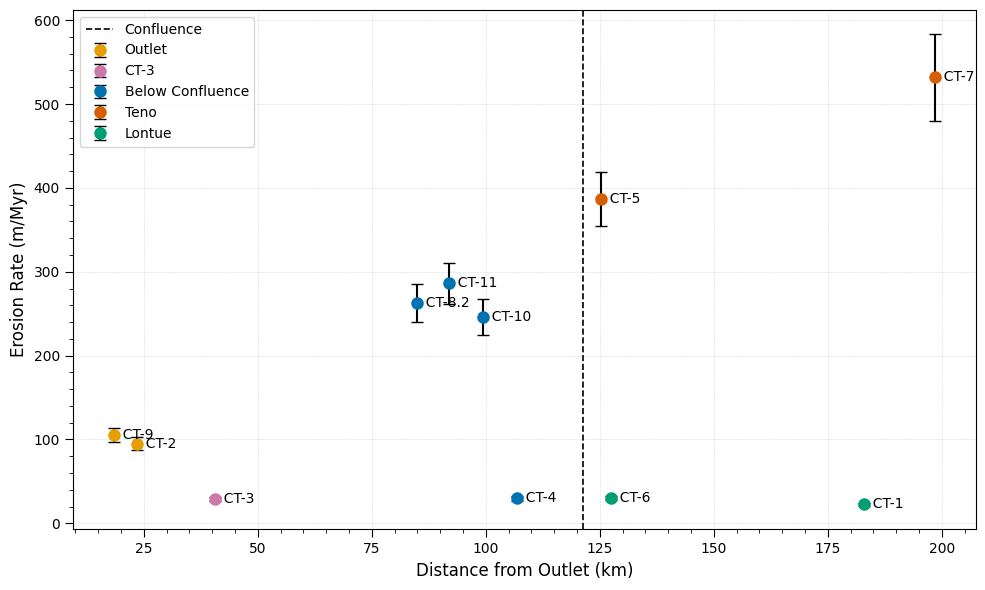

    sample    distance  erosion_rate  erosion_uncert
8     CT-9   18.499550         105.0            8.55
1     CT-2   23.440270          94.8            7.73
2     CT-3   40.525566          29.5            2.42
7   CT-8.2   84.828881         263.0           22.90
10   CT-11   92.014328         286.0           24.50
9    CT-10   99.473719         246.0           21.30
3     CT-4  106.755373          29.6            2.44
4     CT-5  125.321861         387.0           32.00
5     CT-6  127.363514          29.8            2.44
0     CT-1  183.050998          22.9            1.86
6     CT-7  198.483296         532.0           52.00


In [14]:
#Plot erosion rates vs distance from outlet using your Excel data
plot_df = plot_all_samples_from_outlet(df, outlet_distances)

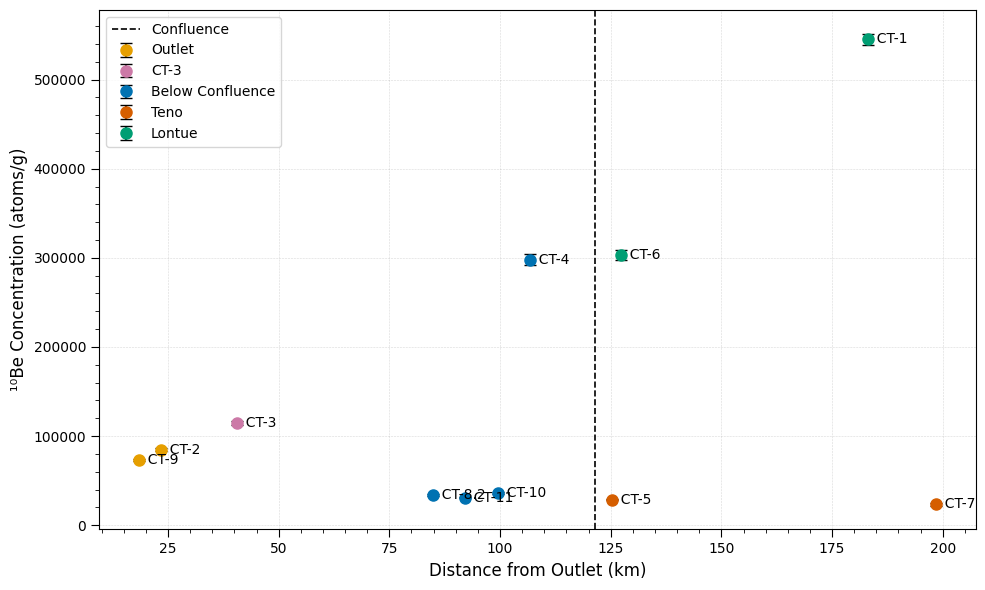

    sample    distance  be10_conc  be10_uncert
8     CT-9   18.499550      73400         1400
1     CT-2   23.440270      84600         1610
2     CT-3   40.525566     115000         2150
7   CT-8.2   84.828881      33800         1240
10   CT-11   92.014328      31100         1040
9    CT-10   99.473719      36400         1280
3     CT-4  106.755373     298000         5920
4     CT-5  125.321861      28800          686
5     CT-6  127.363514     303000         5700
0     CT-1  183.050998     545000         6580
6     CT-7  198.483296      23300         1340


In [15]:
# Plot Be-10 concentration vs distance from outlet
be10_plot_df = plot_be10_concentration_from_outlet(df, outlet_distances)